# 🗡️ YOLOv26-Based Kris Detection & Classification
## Madura Cultural Heritage Preservation — Google Colab Training Pipeline

Notebook ini melatih dan menguji model **YOLOv26** menggunakan dataset anotasi keris yang dihasilkan dari Dashboard Web (dataset_keris).

> **Catatan:** Class label dibaca **langsung dari folder dataset** sehingga selalu sinkron dengan anotasi terbaru. Kelas dengan sampel sangat sedikit diremap otomatis ke `keris_unknown`.

---

### ⚡ Quick Reference

| Parameter | Nilai | Keterangan |
|-----------|-------|------------|
| `EPOCHS` | `150` | Naikkan ke 200 untuk dataset besar |
| `IMG_SIZE` | `640` | Resolusi input standar YOLO |
| `BATCH` | `auto` | Dideteksi otomatis dari GPU VRAM |
| `MODEL_PT` | `yolo26s.pt` | Small model — akurasi lebih baik dari nano |
| `TRAIN_RATIO` | `0.8` | 80% train / 20% val |
| `RANDOM_SEED` | `42` | Reproducibility |
| `MIN_SAMPLES` | `7` | Minimum sampel per kelas (kelas < ini → unknown) |
| Augmentasi | `mosaic + mixup + copy_paste` | Dataset kecil butuh augmentasi kuat |

### 📋 Urutan Eksekusi

1. ⚙️ Setup Environment (GPU + Dependencies)
2. 📦 Clone Repository & Dataset
3. 🔍 Scan Dataset & Bangun Class Map Dinamis
4. ✂️ Split Dataset Train/Val (dengan class remapping otomatis)
5. 📝 Generate `dataset_keris.yaml`
6. 🏋️ Training YOLOv26 (yolo26s + augmentasi penuh)
7. 📊 Evaluasi & Visualisasi Hasil Training
8. 📷 Webcam Inference Realtime
9. 🖼️ Inference pada Gambar Dataset

## 1. ⚙️ Setup Environment

In [1]:
# Verifikasi GPU T4/A100 aktif
!nvidia-smi
import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA tersedia: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Thu Jun 25 03:33:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Instal semua dependensi yang diperlukan
# PyYAML, opencv, dll sudah tersedia di Colab — install ultralytics saja
!pip install -q 'ultralytics>=8.3.50' PyYAML beautifulsoup4 pillow requests pandas tqdm opencv-python matplotlib
print("✅ Instalasi selesai.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.9 MB/s eta 0:00:00
✅ Instalasi selesai.


## 2. 📦 Clone Repository & Dataset

Kita akan melakukan kloning repositori dari GitHub langsung ke Google Colab agar semua dataset, model, dan modul backend terintegrasi secara otomatis.

In [3]:
# ==========================================
# Clone Repositori dari GitHub
# ==========================================
import os
import subprocess

REPO_URL = 'https://github.com/moh-affan/kris-detection-yolov26.git'
REPO_DIR = '/content/kris-detection-yolov26'
FORCE_RECLONE = False  # Set True untuk memaksa clone ulang

if os.path.exists(REPO_DIR) and not FORCE_RECLONE:
    print(f"📂 Repositori sudah ada di {REPO_DIR} — melewati proses clone.")
    print("   (Set FORCE_RECLONE = True untuk clone ulang dari awal)")
else:
    import shutil
    if os.path.exists(REPO_DIR):
        shutil.rmtree(REPO_DIR)
        print("🗑️  Folder lama dihapus.")

    print(f"📥 Mengkloning repositori kris-detection-yolov26...")
    result = subprocess.run(
        ['git', 'clone', '--depth=1', REPO_URL, REPO_DIR],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        raise RuntimeError(f"❌ Git clone gagal:\n{result.stderr}")
    print("✅ Repositori berhasil dikloning.")

# Verifikasi folder utama ada
assert os.path.exists(REPO_DIR), f"❌ Folder repositori tidak ditemukan: {REPO_DIR}"
print(f"📁 Isi root repo: {os.listdir(REPO_DIR)}")

📥 Mengkloning repositori kris-detection-yolov26...
✅ Repositori berhasil dikloning.
📁 Isi root repo: ['colab', 'Dockerfile', 'split_dataset.py', 'DEPLOY_EDGE.md', 'docker-compose.yml', 'best.pt', 'backend', 'Dockerfile.backend', 'frontend', '.git', 'dataset_keris', 'pyproject.toml', '.gitignore', 'README.md', '.env.example', 'Dockerfile.frontend', 'uv.lock', '.python-version']


## 3. 🔍 Scan Dataset & Bangun Class Map Dinamis

Cell ini membaca label secara otomatis dari:
- **Folder `images/`**: mendaftarkan semua kelas yang ada
- **File `annotations_db.json`**: membaca label YOLO yang benar-benar dipakai di anotasi

Sehingga class map selalu sinkron dengan kondisi dataset nyata.

In [4]:
import os
from pathlib import Path

# Tampilkan struktur direktori dataset
REPO_DIR = '/content/kris-detection-yolov26'
dataset_path = Path(REPO_DIR) / 'dataset_keris'

print(f"📁 Struktur direktori dataset:")
for root, dirs, files in os.walk(str(dataset_path)):
    # Filter folder train/val dari tampilan utama
    dirs[:] = [d for d in sorted(dirs) if d not in ('train', 'val')]
    level = root.replace(str(dataset_path), '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}📂 {os.path.basename(root)}/  ({len(files)} file)")

📁 Struktur direktori dataset:
📂 dataset_keris/  (0 file)
  📂 images/  (0 file)
    📂 keris_carang_soka_/  (1 file)
    📂 keris_carubuk_/  (1 file)
    📂 keris_condong_campur_/  (1 file)
    📂 keris_damar_murub_/  (1 file)
    📂 keris_karno_tinanding_/  (1 file)
    📂 keris_kebo_lajer_/  (3 file)
    📂 keris_luk_11/  (17 file)
    📂 keris_luk_13/  (23 file)
    📂 keris_luk_15/  (1 file)
    📂 keris_luk_17/  (1 file)
    📂 keris_luk_3/  (2 file)
    📂 keris_luk_5/  (19 file)
    📂 keris_luk_7/  (7 file)
    📂 keris_luk_9/  (10 file)
    📂 keris_lurus/  (105 file)
    📂 keris_mangkurat_/  (5 file)
    📂 keris_mundarang_/  (1 file)
    📂 keris_naga_liman_/  (2 file)
    📂 keris_panimbal_/  (2 file)
    📂 keris_parungsari_/  (3 file)
    📂 keris_pasopati_/  (4 file)
    📂 keris_putut_/  (1 file)
    📂 keris_sempana_/  (4 file)
    📂 keris_singo_barong_/  (2 file)
    📂 keris_sinom_/  (3 file)
    📂 keris_unknown/  (19 file)
  📂 labels/  (0 file)
    📂 keris_carang_soka_/  (1 file)
    📂 ker

In [5]:
import os
import json
import shutil
import random
import glob
from collections import Counter, defaultdict
from pathlib import Path

# ── Path konfigurasi ─────────────────────────────────────────────────────────
DATASET_ROOT   = Path('/content/kris-detection-yolov26/dataset_keris')
IMAGES_DIR     = DATASET_ROOT / 'images'
LABELS_DIR     = DATASET_ROOT / 'labels'
METADATA_DIR   = DATASET_ROOT / 'metadata'
ANNOTATIONS_DB = METADATA_DIR / 'annotations_db.json'

assert DATASET_ROOT.exists(), (
    f"❌ Folder dataset tidak ditemukan: {DATASET_ROOT}\n"
    "   Pastikan repositori sudah berhasil di-clone pada langkah sebelumnya."
)

# ── 1. Kumpulkan semua label YOLO yang CONFIRMED dari annotations_db ─────────
yolo_labels_used = set()
annotated_images = {}

if ANNOTATIONS_DB.exists():
    with open(ANNOTATIONS_DB, 'r', encoding='utf-8') as f:
        db = json.load(f)
    for rel_path, data in db.items():
        if data.get('status') != 'done':
            continue
        confirmed_labels = [
            b['label'] for b in data.get('boxes', [])
            if b.get('confirmed') and b.get('label')
        ]
        if confirmed_labels:
            yolo_labels_used.update(confirmed_labels)
            annotated_images[rel_path] = {
                'boxes': data['boxes'],
                'confirmed_labels': confirmed_labels
            }
    print(f"✅ Membaca annotations_db.json — {len(db)} entri, {len(annotated_images)} gambar teranotasi done.")
else:
    print("⚠️ annotations_db.json tidak ditemukan — hanya membaca dari folder images.")
    db = {}

# ── 2. Scan folder images untuk semua kelas yang ada ─────────────────────────
all_image_classes = sorted([
    d.name for d in IMAGES_DIR.iterdir()
    if d.is_dir() and d.name not in ('train', 'val')
])

print(f"\n📁 Ditemukan {len(all_image_classes)} folder kelas di images/:")
class_image_counts = {}
for cls in all_image_classes:
    imgs = list((IMAGES_DIR / cls).glob('*.*'))
    imgs = [f for f in imgs if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    class_image_counts[cls] = len(imgs)
    flag = "✅" if len(imgs) >= 10 else ("⚠️" if len(imgs) >= 5 else "🔴")
    print(f"   {flag} {cls:<35} {len(imgs):>4} gambar")

total_images = sum(class_image_counts.values())
print(f"\n📊 Total gambar: {total_images}")

# ── 3. Scan folder labels ─────────────────────────────────────────────────────
labeled_classes = sorted([
    d.name for d in LABELS_DIR.iterdir()
    if d.is_dir() and d.name not in ('train', 'val')
]) if LABELS_DIR.exists() else []

print(f"\n🏷️  Ditemukan {len(labeled_classes)} folder kelas di labels/:")
class_label_counts = {}
for cls in labeled_classes:
    txts = list((LABELS_DIR / cls).glob('*.txt'))
    class_label_counts[cls] = len(txts)
    print(f"   {cls:<35} {len(txts):>4} label .txt")

# ── 4. CLASS MAP — sinkron dengan folder dataset aktual ───────────────────────
#
# Strategi: kelas dengan ≥ MIN_SAMPLES gambar → kelas mandiri
#           kelas dengan < MIN_SAMPLES gambar → diremap ke keris_unknown
#
MIN_SAMPLES = 7  # Minimum sampel agar kelas layak dilatih sendiri

# Kelas prioritas: selalu masuk terlepas dari jumlah sampel
PRIORITY_CLASSES = [
    "keris_lurus",    # 105 gambar — kelas utama
    "keris_luk_3",    #   2 gambar — tetap dipertahankan (khas budaya)
    "keris_luk_5",    #  19 gambar
    "keris_luk_7",    #   7 gambar
    "keris_luk_9",    #  10 gambar
    "keris_luk_11",   #  17 gambar
    "keris_luk_13",   #  23 gambar
    "keris_unknown",  #  19 gambar — kelas catch-all
]

# Kelas dapur dengan sampel cukup → masuk sebagai kelas mandiri
DAPUR_CLASSES = sorted([
    cls for cls in all_image_classes
    if cls not in PRIORITY_CLASSES and class_image_counts.get(cls, 0) >= MIN_SAMPLES
])

CLASS_NAMES = PRIORITY_CLASSES + DAPUR_CLASSES

# Remap kelas kecil → keris_unknown
REMAP_TO_UNKNOWN = [
    cls for cls in all_image_classes
    if cls not in CLASS_NAMES
]

CLASS_MAP = {label: idx for idx, label in enumerate(CLASS_NAMES)}
NC = len(CLASS_NAMES)

print(f"\n🗺️  CLASS MAP (MIN_SAMPLES={MIN_SAMPLES}):")
print(f"   Jumlah kelas aktif (nc): {NC}")
print("   ID → Label → Sampel:")
for idx, label in enumerate(CLASS_NAMES):
    count = class_image_counts.get(label, 0)
    bar = "█" * min(count, 20) + ("+" if count > 20 else "")
    print(f"     {idx:>2}: {label:<35} {count:>4}  {bar}")

if REMAP_TO_UNKNOWN:
    print(f"\n   ♻️  Kelas diremap → keris_unknown ({len(REMAP_TO_UNKNOWN)} kelas):")
    for cls in REMAP_TO_UNKNOWN:
        print(f"      - {cls} ({class_image_counts.get(cls,0)} gambar)")

✅ Membaca annotations_db.json — 239 entri, 239 gambar teranotasi done.

📁 Ditemukan 26 folder kelas di images/:
   🔴 keris_carang_soka_                     1 gambar
   🔴 keris_carubuk_                         1 gambar
   🔴 keris_condong_campur_                  1 gambar
   🔴 keris_damar_murub_                     1 gambar
   🔴 keris_karno_tinanding_                 1 gambar
   🔴 keris_kebo_lajer_                      3 gambar
   ✅ keris_luk_11                          17 gambar
   ✅ keris_luk_13                          23 gambar
   🔴 keris_luk_15                           1 gambar
   🔴 keris_luk_17                           1 gambar
   🔴 keris_luk_3                            2 gambar
   ✅ keris_luk_5                           19 gambar
   ⚠️ keris_luk_7                            7 gambar
   ✅ keris_luk_9                           10 gambar
   ✅ keris_lurus                          105 gambar
   ⚠️ keris_mangkurat_                       5 gambar
   🔴 keris_mundarang_                 

## 3b. 🔄 Regenerasi Label dari Anotasi Manual

Cell ini **meregenerasi ulang semua file label `.txt`** langsung dari `annotations_db.json` sebagai sumber kebenaran tunggal (*ground truth*).

> ⚠️ **Mengapa ini penting?**
> - Nama folder gambar (e.g. `keris_kebo_lajer_`) ≠ label yang dianotasi (`keris_lurus`)
> - File `.txt` lama mungkin menggunakan class map yang salah
> - Cell ini memastikan setiap label `.txt` mencerminkan hasil anotasi manual yang sesungguhnya

In [6]:
import json
import shutil
from pathlib import Path

print("🔄 Meregenerasi label .txt dari annotations_db.json...")
print(f"   Ground truth: {ANNOTATIONS_DB}")
print()

# ── Validasi ──────────────────────────────────────────────────────────────────
assert ANNOTATIONS_DB.exists(), "❌ annotations_db.json tidak ditemukan!"
assert CLASS_MAP, "❌ CLASS_MAP kosong — jalankan Cell 8 terlebih dahulu!"

with open(ANNOTATIONS_DB, 'r', encoding='utf-8') as f:
    db = json.load(f)

# ── Sanitasi label edge-case ───────────────────────────────────────────────────
def sanitize_label(label, luk=None):
    """Bersihkan label yang tidak valid atau tidak ada di CLASS_MAP."""
    if not label or 'NaN' in str(label):
        # Fallback: coba rekonstruksi dari nilai luk
        if luk is not None and not (isinstance(luk, float) and luk != luk):  # NaN check
            luk_int = int(luk)
            if luk_int == 0:
                return 'keris_lurus'
            candidate = f'keris_luk_{luk_int}'
            if candidate in CLASS_MAP:
                return candidate
        return 'keris_unknown'
    # Normalisasi: hapus trailing underscore jika ada versi tanpa
    if label not in CLASS_MAP:
        stripped = label.rstrip('_')
        if stripped in CLASS_MAP:
            return stripped
    return label

# ── Statistik ─────────────────────────────────────────────────────────────────
stats = {
    'regenerated': 0,
    'skipped_no_box': 0,
    'skipped_unconfirmed': 0,
    'remapped_to_unknown': 0,
    'multi_box': 0,
    'errors': []
}
label_distribution = {}

# ── Regenerasi file .txt ───────────────────────────────────────────────────────
for rel_path, data in db.items():
    if data.get('status') != 'done':
        stats['skipped_unconfirmed'] += 1
        continue

    # Parse path
    parts_path = rel_path.split('/')
    folder  = parts_path[0]
    fname   = parts_path[-1]
    stem    = Path(fname).stem

    # Ambil semua box yang confirmed
    all_boxes = data.get('boxes', [])
    conf_boxes = [b for b in all_boxes if b.get('confirmed') == True]

    if not conf_boxes:
        stats['skipped_no_box'] += 1
        continue

    if len(conf_boxes) > 1:
        stats['multi_box'] += 1

    # Lokasi file label .txt yang akan diregenerasi
    label_path = LABELS_DIR / folder / (stem + '.txt')

    if not label_path.exists():
        stats['errors'].append(f"Tidak ditemukan: {label_path}")
        continue

    # Tulis ulang file label dengan class ID yang benar
    new_lines = []
    for box in conf_boxes:
        raw_label = box.get('label', '')
        luk_val   = box.get('luk')
        gt_label  = sanitize_label(raw_label, luk_val)

        # Tentukan class ID dari CLASS_MAP
        if gt_label in CLASS_MAP:
            cls_id = CLASS_MAP[gt_label]
        else:
            # Remap ke unknown
            cls_id = CLASS_MAP.get('keris_unknown', len(CLASS_NAMES) - 1)
            gt_label = 'keris_unknown'
            stats['remapped_to_unknown'] += 1

        # Koordinat YOLO center format
        x, y, w, h = box['x'], box['y'], box['w'], box['h']
        cx = x + w / 2
        cy = y + h / 2

        # Validasi koordinat
        if not all(0.0 <= v <= 1.0 for v in [cx, cy, w, h]):
            stats['errors'].append(f"Koordinat out-of-range: {rel_path} ({cx:.3f},{cy:.3f})")
            continue

        new_lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
        label_distribution[gt_label] = label_distribution.get(gt_label, 0) + 1

    if new_lines:
        with open(label_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(new_lines) + '\n')
        stats['regenerated'] += 1

# ── Laporan ───────────────────────────────────────────────────────────────────
print("=" * 60)
print("📋 LAPORAN REGENERASI LABEL")
print("=" * 60)
print(f"  ✅ Label .txt diregenerasi : {stats['regenerated']}")
print(f"  📦 Multi-box per gambar   : {stats['multi_box']}")
print(f"  ♻️  Diremap ke unknown     : {stats['remapped_to_unknown']}")
print(f"  ⏭️  Dilewati (no box)      : {stats['skipped_no_box']}")
print(f"  ❌ Error                  : {len(stats['errors'])}")
if stats['errors']:
    for e in stats['errors'][:5]:
        print(f"     - {e}")

print(f"\n📊 Distribusi label setelah regenerasi:")
print(f"  {'LABEL':<35} {'COUNT':>6}  BAR")
print("  " + "-" * 60)
for label, count in sorted(label_distribution.items(), key=lambda x: -x[1]):
    cls_id = CLASS_MAP.get(label, '?')
    bar = "█" * min(count, 40) + ("+" if count > 40 else "")
    print(f"  [{cls_id:>2}] {label:<30} {count:>6}  {bar}")

print(f"\n✅ Regenerasi selesai! Label .txt sekarang sinkron dengan annotations_db.json")

🔄 Meregenerasi label .txt dari annotations_db.json...
   Ground truth: /content/kris-detection-yolov26/dataset_keris/metadata/annotations_db.json

📋 LAPORAN REGENERASI LABEL
  ✅ Label .txt diregenerasi : 239
  📦 Multi-box per gambar   : 10
  ♻️  Diremap ke unknown     : 3
  ⏭️  Dilewati (no box)      : 0
  ❌ Error                  : 0

📊 Distribusi label setelah regenerasi:
  LABEL                                COUNT  BAR
  ------------------------------------------------------------
  [ 0] keris_lurus                       135  ████████████████████████████████████████+
  [ 2] keris_luk_5                        30  ██████████████████████████████
  [ 6] keris_luk_13                       28  ████████████████████████████
  [ 3] keris_luk_7                        19  ███████████████████
  [ 5] keris_luk_11                       15  ███████████████
  [ 4] keris_luk_9                        14  ██████████████
  [ 7] keris_unknown                       6  ██████
  [ 1] keris_luk_3          

## 4. ✂️ Split Dataset Train/Val

Membagi dataset per kelas dengan rasio **80% train / 20% val**.
Hanya gambar yang **memiliki file label `.txt`** yang dimasukkan ke split (gambar tanpa label diabaikan untuk training, agar tidak error).

In [7]:
import random
import shutil
from pathlib import Path

TRAIN_RATIO = 0.8
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Bersihkan dan buat ulang folder train/val
for split in ['train', 'val']:
    split_img_dir = IMAGES_DIR / split
    split_lbl_dir = LABELS_DIR / split
    if split_img_dir.exists(): shutil.rmtree(split_img_dir)
    if split_lbl_dir.exists(): shutil.rmtree(split_lbl_dir)
    split_img_dir.mkdir(exist_ok=True)
    split_lbl_dir.mkdir(exist_ok=True)

train_count = 0
val_count   = 0
skipped     = 0
remapped    = 0

# Index kelas unknown untuk remap
unknown_idx = CLASS_MAP.get('keris_unknown', len(CLASS_NAMES) - 1)

print("🔀 Memulai split dataset...\n")

for cls in all_image_classes:
    cls_img_dir   = IMAGES_DIR / cls
    cls_label_dir = LABELS_DIR / cls

    # Tentukan target class index
    if cls in CLASS_MAP:
        target_cls_idx = CLASS_MAP[cls]
        is_remapped = False
    else:
        # Remap kelas kecil ke keris_unknown
        target_cls_idx = unknown_idx
        is_remapped = True

    # Kumpulkan gambar yang punya label .txt yang valid
    paired = []
    for img_file in cls_img_dir.iterdir():
        if img_file.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        label_file = cls_label_dir / (img_file.stem + '.txt')
        if label_file.exists() and label_file.stat().st_size > 0:
            paired.append((img_file, label_file))
        else:
            skipped += 1

    if not paired:
        print(f"   ⚠️  {cls}: tidak ada pasangan image+label — dilewati")
        continue

    random.shuffle(paired)
    split_idx   = max(1, int(len(paired) * TRAIN_RATIO))
    train_files = paired[:split_idx]
    val_files   = paired[split_idx:]
    if not val_files and len(paired) > 1:
        val_files   = paired[-1:]
        train_files = paired[:-1]

    for img_f, lbl_f in train_files:
        # Salin gambar
        shutil.copy2(img_f, IMAGES_DIR / 'train' / img_f.name)
        # Tulis ulang label dengan class ID yang benar (remap jika perlu)
        dst_lbl = LABELS_DIR / 'train' / lbl_f.name
        with open(lbl_f, 'r') as fin:
            lines = fin.readlines()
        with open(dst_lbl, 'w') as fout:
            for line in lines:
                parts = line.strip().split()
                if parts:
                    parts[0] = str(target_cls_idx)  # update class ID
                    fout.write(' '.join(parts) + '\n')
        train_count += 1
        if is_remapped: remapped += 1

    for img_f, lbl_f in val_files:
        shutil.copy2(img_f, IMAGES_DIR / 'val' / img_f.name)
        dst_lbl = LABELS_DIR / 'val' / lbl_f.name
        with open(lbl_f, 'r') as fin:
            lines = fin.readlines()
        with open(dst_lbl, 'w') as fout:
            for line in lines:
                parts = line.strip().split()
                if parts:
                    parts[0] = str(target_cls_idx)
                    fout.write(' '.join(parts) + '\n')
        val_count += 1

    remap_tag = f" → ♻️ remap ke keris_unknown" if is_remapped else ""
    print(f"   {'♻️' if is_remapped else '✅'} {cls:<35} train:{len(train_files):>3}  val:{len(val_files):>3}{remap_tag}")

print(f"\n{'='*60}")
print(f"   Total train  : {train_count} gambar")
print(f"   Total val    : {val_count} gambar")
print(f"   Dilewati     : {skipped} gambar (tidak ada label)")
print(f"   Diremap      : {remapped} gambar → keris_unknown")
print(f"{'='*60}")

if train_count == 0:
    print("\n❌ Tidak ada gambar berhasil di-split!")
else:
    print("\n✅ Split selesai — siap untuk training!")

🔀 Memulai split dataset...

   ♻️ keris_carang_soka_                  train:  1  val:  0 → ♻️ remap ke keris_unknown
   ♻️ keris_carubuk_                      train:  1  val:  0 → ♻️ remap ke keris_unknown
   ♻️ keris_condong_campur_               train:  1  val:  0 → ♻️ remap ke keris_unknown
   ♻️ keris_damar_murub_                  train:  1  val:  0 → ♻️ remap ke keris_unknown
   ♻️ keris_karno_tinanding_              train:  1  val:  0 → ♻️ remap ke keris_unknown
   ♻️ keris_kebo_lajer_                   train:  2  val:  1 → ♻️ remap ke keris_unknown
   ✅ keris_luk_11                        train: 13  val:  4
   ✅ keris_luk_13                        train: 18  val:  5
   ♻️ keris_luk_15                        train:  1  val:  0 → ♻️ remap ke keris_unknown
   ♻️ keris_luk_17                        train:  1  val:  0 → ♻️ remap ke keris_unknown
   ✅ keris_luk_3                         train:  1  val:  1
   ✅ keris_luk_5                         train: 15  val:  4
   ✅ keris_luk_7    

## 5. 📝 Generate `dataset_keris.yaml`

File YAML dibuat secara **dinamis** berdasarkan class map yang telah dibangun.

In [8]:
import yaml

YAML_PATH = Path('/content/dataset_keris.yaml')

# Cek apakah folder val kosong (fallback ke train)
val_imgs = list((IMAGES_DIR / 'val').glob('*.*')) if (IMAGES_DIR / 'val').exists() else []
val_path = 'images/val' if val_imgs else 'images/train'

dataset_config = {
    'path': str(DATASET_ROOT),
    'train': 'images/train',
    'val': val_path,
    'nc': NC,
    'names': CLASS_NAMES
}

with open(YAML_PATH, 'w', encoding='utf-8') as f:
    yaml.dump(dataset_config, f, default_flow_style=False, allow_unicode=True)

# Tampilkan isi YAML
print(f"✅ dataset_keris.yaml berhasil dibuat: {YAML_PATH}")
print(f"   val path: {val_path} {'(fallback ke train — dataset val kosong)' if val_path == 'images/train' else ''}")
print("\n📄 Isi file YAML:")
print("-" * 50)
with open(YAML_PATH, 'r') as f:
    print(f.read())

✅ dataset_keris.yaml berhasil dibuat: /content/dataset_keris.yaml
   val path: images/val 

📄 Isi file YAML:
--------------------------------------------------
names:
- keris_lurus
- keris_luk_3
- keris_luk_5
- keris_luk_7
- keris_luk_9
- keris_luk_11
- keris_luk_13
- keris_unknown
nc: 8
path: /content/kris-detection-yolov26/dataset_keris
train: images/train
val: images/val



## 6. 🏋️ Training YOLOv26

Model dilatih menggunakan GPU T4/A100 yang tersedia di Google Colab.

| Parameter | Nilai | Keterangan |
|---|---|---|
| `epochs` | 50 | Jumlah iterasi penuh (naikkan ke 100+ untuk dataset besar) |
| `imgsz` | 640 | Resolusi input gambar (standar YOLO) |
| `batch` | 16 | Batch size (turunkan ke 8 jika OOM) |
| `device` | 0 | GPU index (0 = GPU pertama) |

In [9]:
# Verifikasi sebelum training
train_imgs = list((IMAGES_DIR / 'train').glob('*.*'))
train_lbls = list((LABELS_DIR / 'train').glob('*.txt'))

print("🔍 Verifikasi pra-training:")
print(f"   Gambar train  : {len(train_imgs)}")
print(f"   Label train   : {len(train_lbls)}")
print(f"   YAML path     : {YAML_PATH}")
print(f"   Jumlah kelas  : {NC}")
print(f"   Class list    : {CLASS_NAMES}")

if len(train_imgs) == 0:
    print("\n❌ Tidak ada gambar di folder train! Training dibatalkan.")
    print("   Periksa langkah upload dan split dataset.")
elif len(train_lbls) == 0:
    print("\n❌ Tidak ada label .txt di folder train! Training dibatalkan.")
else:
    print("\n✅ Semua siap untuk training!")

🔍 Verifikasi pra-training:
   Gambar train  : 187
   Label train   : 187
   YAML path     : /content/dataset_keris.yaml
   Jumlah kelas  : 8
   Class list    : ['keris_lurus', 'keris_luk_3', 'keris_luk_5', 'keris_luk_7', 'keris_luk_9', 'keris_luk_11', 'keris_luk_13', 'keris_unknown']

✅ Semua siap untuk training!


In [10]:
from ultralytics import YOLO
import torch
import os

# ── Konfigurasi Training ──────────────────────────────────────────────────────
EPOCHS    = 150      # Lebih banyak epoch untuk dataset kecil
IMG_SIZE  = 640
MODEL_PT  = 'yolo26s.pt'   # Small model — lebih akurat dari nano
PROJECT   = '/content/runs/keris'
RUN_NAME  = 'yolov26_madura_kris'
RESUME    = False    # Set True untuk melanjutkan training yang terputus

# ── Auto-detect batch size berdasarkan GPU VRAM ───────────────────────────────
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    if vram_gb >= 20:
        BATCH = 32
    elif vram_gb >= 12:
        BATCH = 16
    elif vram_gb >= 8:
        BATCH = 8
    else:
        BATCH = 4
    print(f"🖥️  GPU: {torch.cuda.get_device_name(0)} — VRAM: {vram_gb:.1f} GB → batch={BATCH}")
else:
    BATCH = 4
    print("⚠️  GPU tidak terdeteksi — menggunakan CPU dengan batch=4 (sangat lambat)")

# ── Muat model ────────────────────────────────────────────────────────────────
DEVICE     = 0 if torch.cuda.is_available() else 'cpu'
CHECKPOINT = f'{PROJECT}/{RUN_NAME}/weights/last.pt'

if RESUME and os.path.exists(CHECKPOINT):
    print(f"🔄 Melanjutkan training dari checkpoint: {CHECKPOINT}")
    model = YOLO(CHECKPOINT)
else:
    model = YOLO(MODEL_PT)
    print(f"✅ Model dimuat: {MODEL_PT}")

print(f"   Device  : {DEVICE}")
print(f"   Epochs  : {EPOCHS}")
print(f"   Batch   : {BATCH}")
print(f"   ImgSz   : {IMG_SIZE}")
print(f"   Classes : {NC} kelas")

# ── Mulai training dengan augmentasi ─────────────────────────────────────────
results = model.train(
    data       = str(YAML_PATH),
    epochs     = EPOCHS,
    imgsz      = IMG_SIZE,
    batch      = BATCH,
    device     = DEVICE,
    project    = PROJECT,
    name       = RUN_NAME,
    exist_ok   = True,
    patience   = 30,          # Early stopping lebih toleran

    # ── Augmentasi — sangat penting untuk dataset kecil ───────────────────
    hsv_h      = 0.015,       # Variasi hue (warna)
    hsv_s      = 0.7,         # Variasi saturasi
    hsv_v      = 0.4,         # Variasi brightness
    degrees    = 15.0,        # Rotasi ±15° (keris bisa miring)
    translate  = 0.1,         # Translasi ±10%
    scale      = 0.5,         # Zoom ±50%
    shear      = 5.0,         # Shear ±5°
    perspective= 0.0005,      # Distorsi perspektif ringan
    flipud     = 0.0,         # Jangan flip vertikal (keris punya orientasi)
    fliplr     = 0.5,         # Flip horizontal OK
    mosaic     = 1.0,         # Gabung 4 gambar — sangat membantu dataset kecil
    mixup      = 0.15,        # Blend 2 gambar — generalisasi lebih baik
    copy_paste = 0.1,         # Copy-paste objek antar gambar
    erasing    = 0.4,         # Random erasing — robustness terhadap occlusion

    # ── Optimizer & Learning Rate ──────────────────────────────────────────
    optimizer  = 'AdamW',     # Lebih stabil dari SGD untuk dataset kecil
    lr0        = 0.001,       # Learning rate awal
    lrf        = 0.01,        # Learning rate final (lr0 * lrf)
    momentum   = 0.937,
    weight_decay = 0.0005,
    warmup_epochs = 5.0,      # Warmup lebih panjang

    # ── Output ────────────────────────────────────────────────────────────
    resume     = RESUME,
    save       = True,
    save_period= 10,          # Simpan checkpoint setiap 10 epoch
    plots      = True,
    verbose    = True,
)

print("\n🎉 Training selesai!")
BEST_MODEL = Path(PROJECT) / RUN_NAME / 'weights' / 'best.pt'
LAST_MODEL = Path(PROJECT) / RUN_NAME / 'weights' / 'last.pt'
print(f"   Model terbaik  : {BEST_MODEL}")
print(f"   Model terakhir : {LAST_MODEL}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🖥️  GPU: Tesla T4 — VRAM: 15.6 GB → batch=16
✅ Model dimuat: yolo26s.pt
   Device  : 0
   Epochs  : 150
   Batch   : 16
   ImgSz   : 640
   Classes : 8 kelas
Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_keris.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, em

In [11]:
from google.colab import files
from pathlib import Path

BEST_MODEL = Path('/content/runs/keris/yolov26_madura_kris/weights/best.pt')
LAST_MODEL = Path('/content/runs/keris/yolov26_madura_kris/weights/last.pt')

if BEST_MODEL.exists():
    print(f"📥 Mengunduh best.pt ({BEST_MODEL.stat().st_size / 1e6:.1f} MB)...")
    files.download(str(BEST_MODEL))
else:
    print("⚠️  best.pt tidak ditemukan — pastikan training sudah selesai.")

if LAST_MODEL.exists():
    print(f"📥 Mengunduh last.pt ({LAST_MODEL.stat().st_size / 1e6:.1f} MB)...")
    files.download(str(LAST_MODEL))
else:
    print("⚠️  last.pt tidak ditemukan — pastikan training sudah selesai.")

📥 Mengunduh best.pt (20.3 MB)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Mengunduh last.pt (20.3 MB)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. 📊 Evaluasi & Visualisasi Hasil Training

In [12]:
# Tampilkan metrik evaluasi model setelah training
import pandas as pd
from pathlib import Path

RUN_DIR = Path('/content/runs/keris/yolov26_madura_kris')
results_csv = RUN_DIR / 'results.csv'

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    # Ambil epoch terbaik berdasarkan mAP50
    if 'metrics/mAP50(B)' in df.columns:
        best_idx = df['metrics/mAP50(B)'].idxmax()
        best = df.iloc[best_idx]

        print("=" * 55)
        print("🏆  HASIL TRAINING — EPOCH TERBAIK")
        print("=" * 55)
        print(f"   Epoch          : {int(best.get('epoch', best_idx)) + 1} / {len(df)}")
        print(f"   mAP@50         : {best.get('metrics/mAP50(B)', 0):.4f}")
        print(f"   mAP@50-95      : {best.get('metrics/mAP50-95(B)', 0):.4f}")
        print(f"   Precision      : {best.get('metrics/precision(B)', 0):.4f}")
        print(f"   Recall         : {best.get('metrics/recall(B)', 0):.4f}")
        print(f"   Box Loss (val) : {best.get('val/box_loss', 0):.4f}")
        print(f"   Cls Loss (val) : {best.get('val/cls_loss', 0):.4f}")
        print("=" * 55)

        # Epoch terakhir
        last = df.iloc[-1]
        print(f"\n📉 Epoch Terakhir ({len(df)}):")
        print(f"   mAP@50    : {last.get('metrics/mAP50(B)', 0):.4f}")
        print(f"   mAP@50-95 : {last.get('metrics/mAP50-95(B)', 0):.4f}")
    else:
        print("⚠️  Kolom metrik tidak ditemukan. Cek nama kolom:")
        print(df.columns.tolist())
        print(df.tail(3))
else:
    print("⚠️  results.csv tidak ditemukan. Jalankan training terlebih dahulu.")
    print(f"   Path yang dicari: {results_csv}")

🏆  HASIL TRAINING — EPOCH TERBAIK
   Epoch          : 63 / 125
   mAP@50         : 0.3360
   mAP@50-95      : 0.1883
   Precision      : 0.5026
   Recall         : 0.3314
   Box Loss (val) : 1.6048
   Cls Loss (val) : 1.7748

📉 Epoch Terakhir (125):
   mAP@50    : 0.2695
   mAP@50-95 : 0.1846


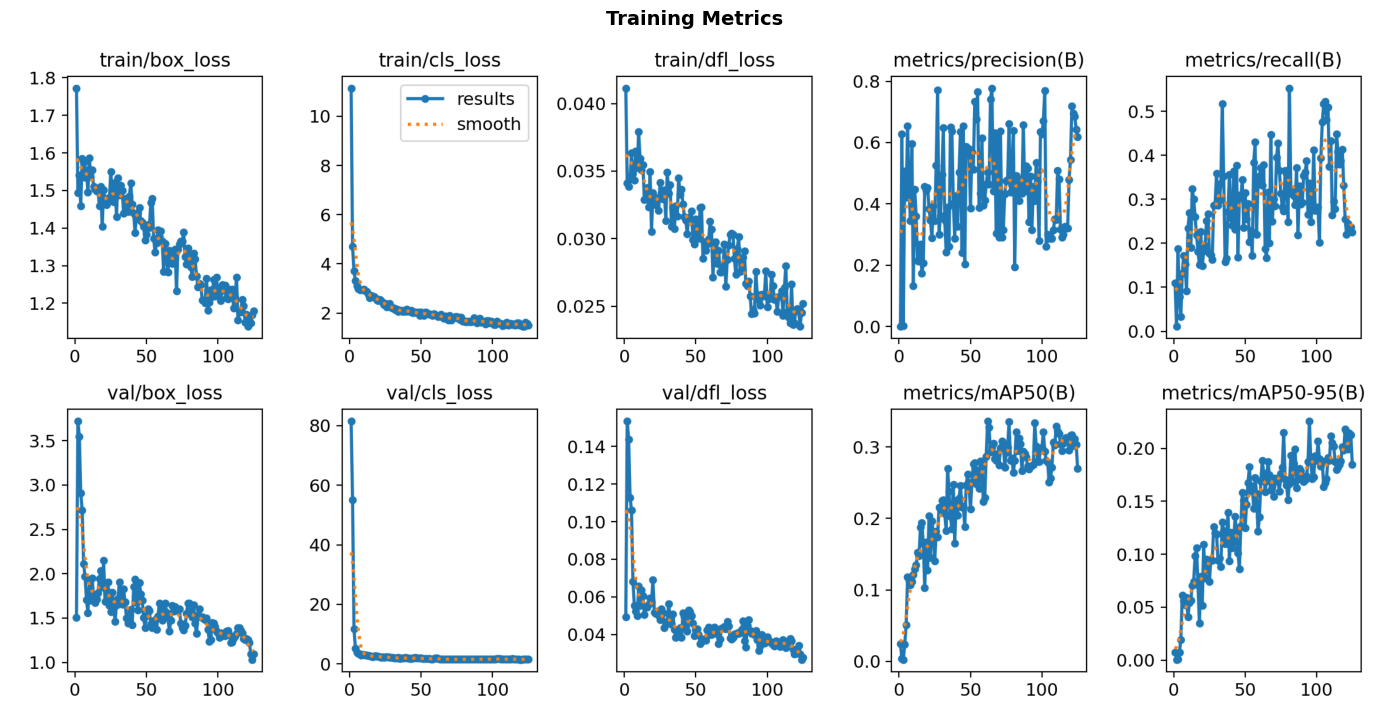

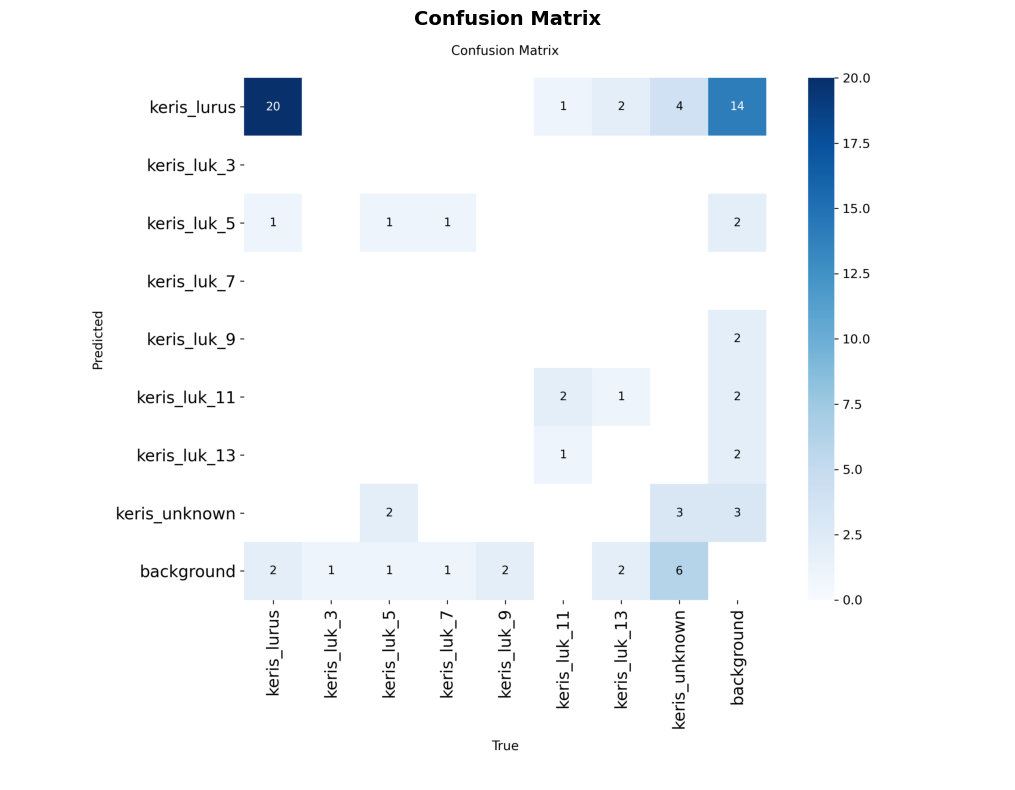

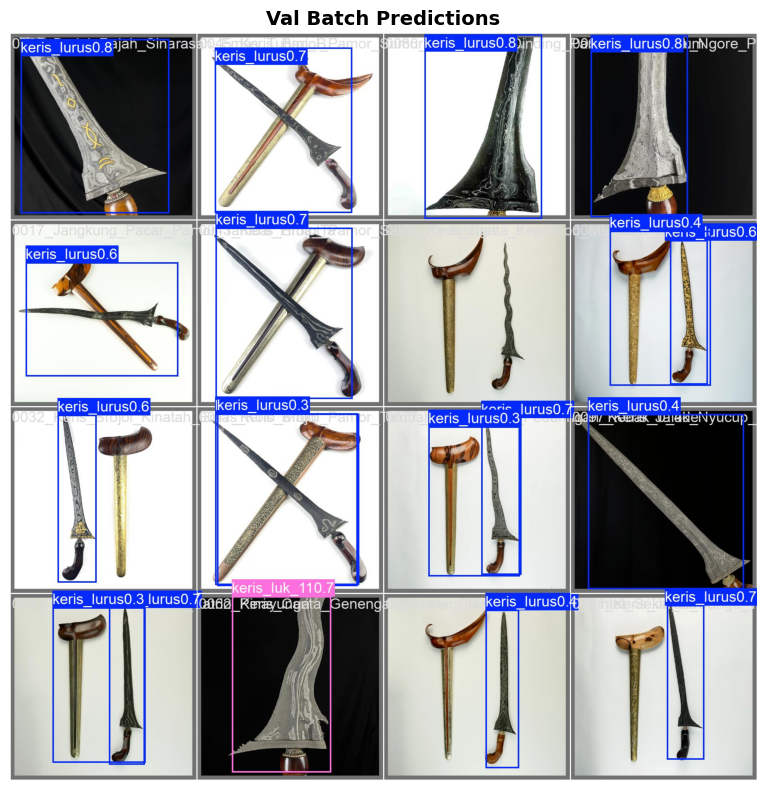


📈 Validasi model terbaik pada val set...
Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,468,276 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2815.8±723.9 MB/s, size: 251.8 KB)
val: Scanning /content/kris-detection-yolov26/dataset_keris/labels/val.cache... 52 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 52/52 21.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3it/s 3.1s
                   all         52         54       0.41      0.336      0.334      0.226
           keris_lurus         21         23      0.382          1      0.694      0.489
           keris_luk_3          1          1          1          0          0          0
           keris_luk_5          4          4     0.0726       0.25      0.313      0.244
           keris_luk_7          2          2          1          0   

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import os

RUN_DIR = Path(PROJECT) / RUN_NAME

# Tampilkan grafik training
plot_files = [
    ('results.png', 'Training Metrics'),
    ('confusion_matrix.png', 'Confusion Matrix'),
    ('val_batch0_pred.jpg', 'Val Batch Predictions'),
]

for fname, title in plot_files:
    fpath = RUN_DIR / fname
    if fpath.exists():
        fig, ax = plt.subplots(figsize=(14, 8))
        img = mpimg.imread(str(fpath))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f"   ℹ️  {fname} belum tersedia")

# Validasi metrik pada val set
print("\n📈 Validasi model terbaik pada val set...")
if BEST_MODEL.exists():
    model_best = YOLO(str(BEST_MODEL))
    metrics = model_best.val(
        data   = str(YAML_PATH),
        imgsz  = IMG_SIZE,
        device = 0 if torch.cuda.is_available() else 'cpu',
        verbose= True
    )
    print(f"\n📊 Hasil Validasi:")
    print(f"   mAP@0.5     : {metrics.box.map50:.4f}")
    print(f"   mAP@0.5:0.95: {metrics.box.map:.4f}")
    print(f"   Precision   : {metrics.box.mp:.4f}")
    print(f"   Recall      : {metrics.box.mr:.4f}")
else:
    print("   ⚠️ best.pt belum tersedia — jalankan training terlebih dahulu.")

In [15]:
# Simpan model terbaik ke Google Drive
import shutil
from pathlib import Path
from google.colab import drive

# Mount Google Drive (skip jika sudah mounted)
drive.mount('/content/drive', force_remount=False)

DRIVE_DIR       = '/content/drive/MyDrive/YOLOv26_Kris'
DRIVE_BEST_PT   = f'{DRIVE_DIR}/yolov26_kris_best.pt'
DRIVE_LAST_PT   = f'{DRIVE_DIR}/yolov26_kris_last.pt'
DRIVE_YAML_PT   = f'{DRIVE_DIR}/dataset_keris.yaml'

import os
os.makedirs(DRIVE_DIR, exist_ok=True)

BEST_MODEL = Path('/content/runs/keris/yolov26_madura_kris/weights/best.pt')
LAST_MODEL = Path('/content/runs/keris/yolov26_madura_kris/weights/last.pt')

if BEST_MODEL.exists():
    shutil.copy2(str(BEST_MODEL), DRIVE_BEST_PT)
    print(f"✅ best.pt tersimpan ke Google Drive: {DRIVE_BEST_PT}")
else:
    print("⚠️  best.pt tidak ditemukan — training mungkin belum selesai.")

if LAST_MODEL.exists():
    shutil.copy2(str(LAST_MODEL), DRIVE_LAST_PT)
    print(f"✅ last.pt tersimpan ke Google Drive: {DRIVE_LAST_PT}")

# Simpan juga YAML untuk referensi
YAML_PATH = Path('/content/dataset_keris.yaml')
if YAML_PATH.exists():
    shutil.copy2(str(YAML_PATH), DRIVE_YAML_PT)
    print(f"✅ dataset_keris.yaml tersimpan ke Google Drive: {DRIVE_YAML_PT}")

Mounted at /content/drive
✅ best.pt tersimpan ke Google Drive: /content/drive/MyDrive/YOLOv26_Kris/yolov26_kris_best.pt
✅ last.pt tersimpan ke Google Drive: /content/drive/MyDrive/YOLOv26_Kris/yolov26_kris_last.pt
✅ dataset_keris.yaml tersimpan ke Google Drive: /content/drive/MyDrive/YOLOv26_Kris/dataset_keris.yaml


## 8. 📷 Webcam Inference Realtime

Gunakan webcam browser untuk mendeteksi keris secara realtime dengan metadata budaya Madura.

In [16]:
import json
from pathlib import Path

# Coba muat knowledge base dari berbagai kemungkinan lokasi
KB_CANDIDATES = [
    Path('/content/backend/knowledge_base.json'),
    Path('/content/knowledge_base.json'),
    DATASET_ROOT.parent / 'backend' / 'knowledge_base.json',
]

cultural_db = {}
for kb_path in KB_CANDIDATES:
    if kb_path.exists():
        with open(kb_path, 'r', encoding='utf-8') as f:
            cultural_db = json.load(f)
        print(f"✅ Knowledge base dimuat dari: {kb_path}")
        print(f"   Keys: {list(cultural_db.keys())}")
        break
else:
    print("⚠️ knowledge_base.json tidak ditemukan — metadata budaya tidak ditampilkan.")
    print("   Upload file backend/knowledge_base.json dari repositori ke Colab.")

# Peta luk dari nama label
LUK_MAKNA = {
    0:  "Lurus — Kejujuran, kepolosan, kesederhanaan",
    3:  "Luk 3 — Trimurti: keseimbangan penciptaan, pemeliharaan & peleburan",
    5:  "Luk 5 — Pancaindra, lambang kesempurnaan manusia",
    7:  "Luk 7 — Tujuh lapis langit, derajat spiritual tertinggi",
    9:  "Luk 9 — Wali Songo, kepemimpinan spiritual",
    11: "Luk 11 — Kesempurnaan kekuatan batin dan perlindungan",
    13: "Luk 13 — Kesakralan tertinggi, kekuatan magis raja/panglima",
    15: "Luk 15 — Paling langka, wahyu agung raja-dewa",
    17: "Luk 17 — Keagungan spiritual tertinggi",
    27: "Luk 27 — Luar biasa langka, pusaka pewayangan",
}

def extract_luk_from_label(label):
    """Ekstrak jumlah luk dari nama label YOLO."""
    if 'lurus' in label:
        return 0
    if 'luk_' in label:
        try:
            return int(label.split('luk_')[-1].rstrip('_'))
        except:
            pass
    return None

def get_cultural_info(label):
    """Ambil informasi budaya dari knowledge base berdasarkan label YOLO."""
    luk = extract_luk_from_label(label)
    luk_makna = LUK_MAKNA.get(luk, "Luk tidak diketahui")

    # Cari di knowledge base
    kb_luk = cultural_db.get('luk', {})
    luk_info = kb_luk.get(str(luk), {}).get('makna', luk_makna) if luk is not None else luk_makna

    # Contoh dapur berdasarkan luk
    dapur_default = {
        0: 'Tilam Upih / Brojol', 3: 'Ron Warih', 5: 'Carita',
        7: 'Carubuk', 9: 'Sabuk Inten', 11: 'Carang Soka',
        13: 'Sengkelat'
    }
    dapur = dapur_default.get(luk, label.replace('keris_', '').replace('_', ' ').title())

    tangguh = cultural_db.get('tangguh', {}).get('madura', {}).get('nama', 'Tangguh Madura')
    pamor   = list(cultural_db.get('pamor', {}).values())[0].get('nama', 'Beras Wutah') if cultural_db.get('pamor') else 'Beras Wutah'
    unesco  = cultural_db.get('status_budaya', {}).get('unesco', 'UNESCO ICH 2008')

    return {'luk': luk, 'luk_makna': luk_info, 'dapur': dapur, 'tangguh': tangguh, 'pamor': pamor, 'unesco': unesco}

print("✅ Fungsi cultural info siap.")

✅ Knowledge base dimuat dari: /content/kris-detection-yolov26/backend/knowledge_base.json
   Keys: ['dapur', 'pamor', 'empu', 'tangguh', 'warangka', 'luk', 'status_budaya']
✅ Fungsi cultural info siap.


In [17]:
from IPython.display import display, Javascript, HTML
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def take_photo(filename='photo.jpg', quality=0.85):
    """Ambil gambar dari webcam browser melalui JavaScript Colab."""
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      div.style.cssText = 'padding:10px; background:#1a0e00; border-radius:8px; display:inline-block;';

      const label = document.createElement('div');
      label.innerHTML = '🗡️ <b style="color:#C9A84C;">YOLOv26 Kris Detector</b> — Posisikan keris di depan kamera';
      label.style.cssText = 'color:#f5e6c8; font-family:sans-serif; font-size:13px; margin-bottom:8px;';

      const video = document.createElement('video');
      video.style.cssText = 'display:block; border-radius:8px; border:2px solid #C9A84C;';
      video.setAttribute('autoplay', '');
      video.setAttribute('playsinline', '');

      const capture = document.createElement('button');
      capture.textContent = '📸 Capture & Deteksi';
      capture.style.cssText = 'margin-top:8px; background:#C9A84C; color:#0f0800; border:none; padding:10px 24px; border-radius:6px; font-weight:bold; font-size:14px; cursor:pointer; display:block; width:100%;';

      div.appendChild(label);
      div.appendChild(video);
      div.appendChild(capture);
      document.body.appendChild(div);

      try {
        const stream = await navigator.mediaDevices.getUserMedia({video: {facingMode: 'environment', width:{ideal:1280}, height:{ideal:720}}});
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        await new Promise((resolve) => capture.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      } catch(e) {
        div.innerHTML = '<p style="color:red;">❌ Akses kamera gagal: ' + e.message + '</p>';
        return null;
      }
    }
    ''')
    display(js)
    data = eval_js(f'takePhoto({quality})')
    if not data:
        return None
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

print("✅ Fungsi take_photo() siap.")

✅ Fungsi take_photo() siap.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import numpy as np
from IPython.display import display, HTML

# Pilih model: gunakan best.pt jika sudah training, fallback ke pretrained
BEST_MODEL = Path('/content/runs/keris/yolov26_madura_kris/weights/best.pt')
if BEST_MODEL.exists():
    INFER_MODEL_PATH = str(BEST_MODEL)
    print(f"🎯 Menggunakan model fine-tuned: {INFER_MODEL_PATH}")
else:
    INFER_MODEL_PATH = 'yolo26n.pt'
    print(f"⚠️ best.pt tidak ditemukan — menggunakan pretrained: {INFER_MODEL_PATH}")

model_infer = YOLO(INFER_MODEL_PATH)

# Ambil gambar dari webcam
photo_file = take_photo('/content/captured_keris.jpg')

if photo_file:
    img = cv2.imread(photo_file)
    results = model_infer.predict(img, conf=0.25, iou=0.45, verbose=False)

    detections_found = []

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf  = float(box.conf[0].item())
            cls   = int(box.cls[0].item())
            # Gunakan nama dari CLASS_NAMES jika model fine-tuned, else dari r.names
            label = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else r.names.get(cls, 'keris_unknown')
            detections_found.append((x1, y1, x2, y2, conf, label))

            # Gambar bounding box
            cv2.rectangle(img, (x1, y1), (x2, y2), (76, 168, 201), 3)
            text = f"{label} {conf:.0%}"
            (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x1, y1-th-10), (x1+tw+4, y1), (76, 168, 201), -1)
            cv2.putText(img, text, (x1+2, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (15, 8, 0), 2)

    # Tampilkan gambar hasil
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'YOLOv26 Kris Detection — {len(detections_found)} objek terdeteksi', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Tampilkan kartu metadata budaya untuk setiap deteksi
    if not detections_found:
        display(HTML("""
        <div style='background:#1a0e00;border:1px solid #C9A84C44;border-radius:8px;padding:16px;color:#9a8060;font-family:sans-serif;'>
            ℹ️ Tidak ada keris terdeteksi. Pastikan bilah keris terlihat jelas dan pencahayaan cukup.
        </div>"""))

    for i, (x1, y1, x2, y2, conf, label) in enumerate(detections_found):
        info = get_cultural_info(label)
        luk_display = f"Luk {info['luk']}" if info['luk'] is not None and info['luk'] > 0 else "Lurus (0 luk)"

        card_html = f"""
        <div style='background:linear-gradient(135deg,#1a0e00,#2d1a00);border:2px solid #C9A84C;
                    border-radius:10px;padding:18px;color:#f5e6c8;max-width:580px;
                    font-family:sans-serif;margin:10px 0;'>
          <h3 style='margin:0 0 12px;color:#C9A84C;border-bottom:1px solid #C9A84C33;
                     padding-bottom:8px;font-size:15px;'>🗡️ IDENTIFIKASI BUDAYA MADURA #{i+1}</h3>
          <div style='font-size:11px;color:#C9A84C;text-transform:uppercase;'>Deteksi YOLOv26</div>
          <div style='font-size:17px;font-weight:bold;margin:4px 0 14px;'>{label.replace('_',' ').title()} — {conf:.1%}</div>
          <div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;font-size:13px;margin-bottom:12px;'>
            <div><b>⚔️ Perkiraan Dapur:</b> {info['dapur']}</div>
            <div><b>〰️ Jumlah Luk:</b> {luk_display}</div>
            <div><b>✨ Contoh Pamor:</b> {info['pamor']}</div>
            <div><b>🏛️ Tangguh:</b> {info['tangguh']}</div>
          </div>
          <div style='font-size:12px;background:rgba(201,168,76,0.08);padding:10px;
                      border-left:3px solid #C9A84C;border-radius:0 6px 6px 0;margin-bottom:10px;'>
            <b>📜 Makna Filosofis:</b><br/>{info['luk_makna']}
          </div>
          <div style='font-size:11px;color:#90caf9;'>🌐 <b>UNESCO:</b> {info['unesco']}</div>
        </div>"""
        display(HTML(card_html))
else:
    print("❌ Gagal mengambil gambar dari webcam.")

## 9. 🖼️ Inference pada Gambar Dataset (Tanpa Webcam)

Uji model pada beberapa gambar dari dataset yang sudah ada — berguna untuk validasi manual.

🔍 Menjalankan inference pada 6 gambar sample...



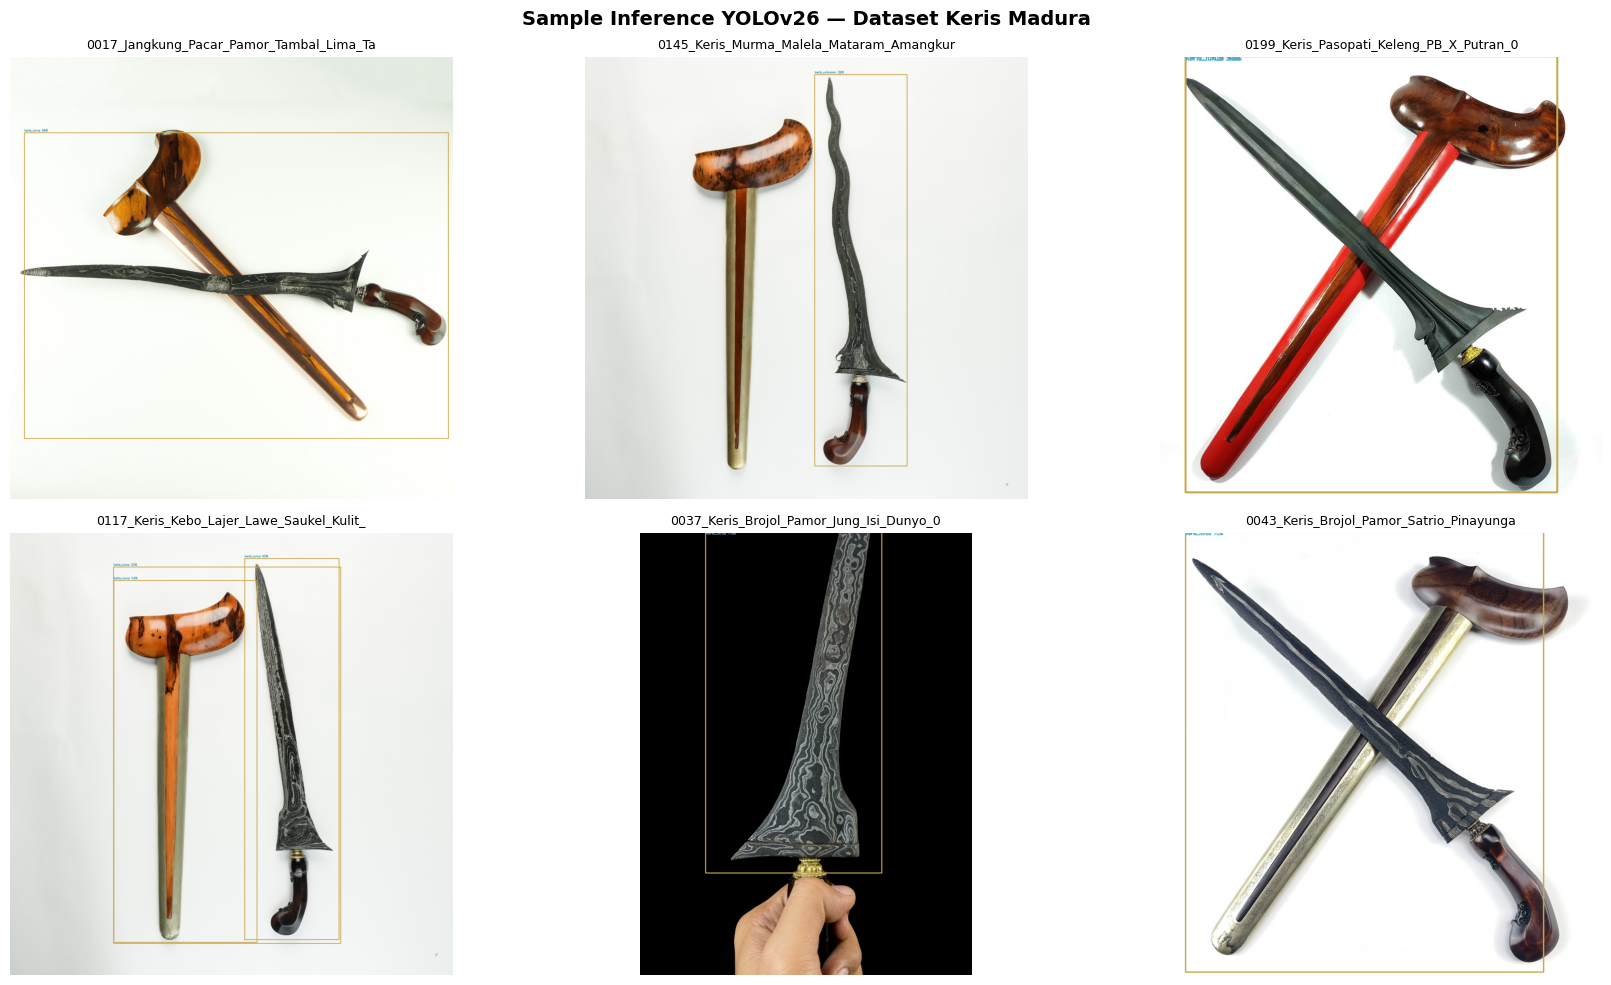

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

random.seed(42)  # Reproducibility

# Ambil sample gambar dari val set
val_image_dir = IMAGES_DIR / 'val'
if not val_image_dir.exists() or not list(val_image_dir.glob('*.*')):
    val_image_dir = IMAGES_DIR / 'train'
    print("ℹ️ Menggunakan gambar dari train set (val set kosong)")

sample_images = random.sample(
    [f for f in val_image_dir.iterdir() if f.suffix.lower() in ('.jpg','.jpeg','.png')],
    k=min(6, len(list(val_image_dir.iterdir())))
)

print(f"🔍 Menjalankan inference pada {len(sample_images)} gambar sample...\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_images):
    img = cv2.imread(str(img_path))
    results = model_infer.predict(img, conf=0.25, verbose=False)

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = float(box.conf[0].item())
            cls  = int(box.cls[0].item())
            label = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else r.names.get(cls, '?')
            cv2.rectangle(img, (x1, y1), (x2, y2), (76, 168, 201), 3)
            cv2.putText(img, f"{label[:20]} {conf:.0%}", (x1, max(y1-8, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (201, 168, 76), 2)

    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name[:40], fontsize=9)
    ax.axis('off')

for ax in axes[len(sample_images):]:
    ax.axis('off')

plt.suptitle('Sample Inference YOLOv26 — Dataset Keris Madura', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()